# 14. Создаем анимацию графиков Классы FuncAnimation и ArtistAnimation

In [3]:
import matplotlib.pyplot as plt
import numpy as np

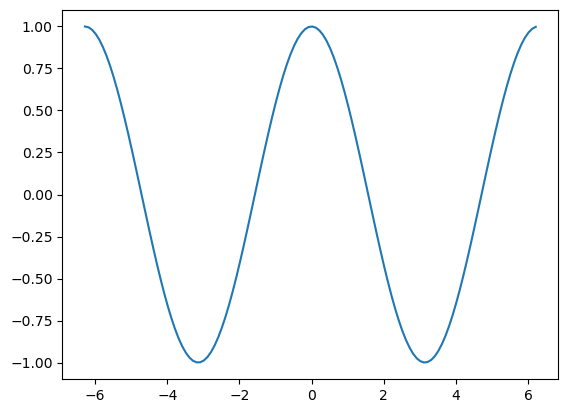

In [4]:
x = np.arange(-2*np.pi, 2*np.pi, 0.1)
y = np.cos(x)

plt.plot(x, y)
plt.show()

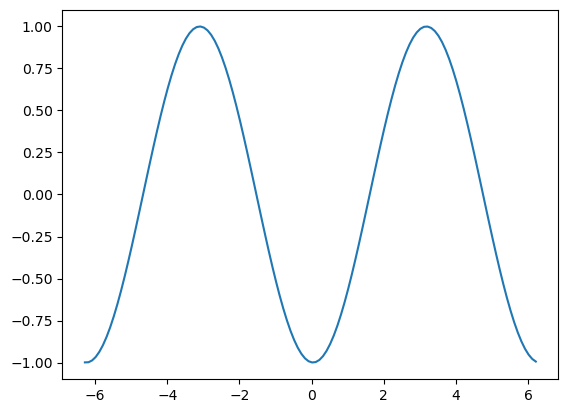

In [5]:
import time

x = np.arange(-2*np.pi, 2*np.pi, 0.1)

plt.ion()
for delay in np.arange(0, np.pi, 0.1):
    y = np.cos(x + delay)

    plt.clf() #очистка окна
    plt.plot(x, y)

    plt.draw()
    plt.gcf().canvas.flush_events()

    time.sleep(0.02)

plt.ioff()
plt.show()

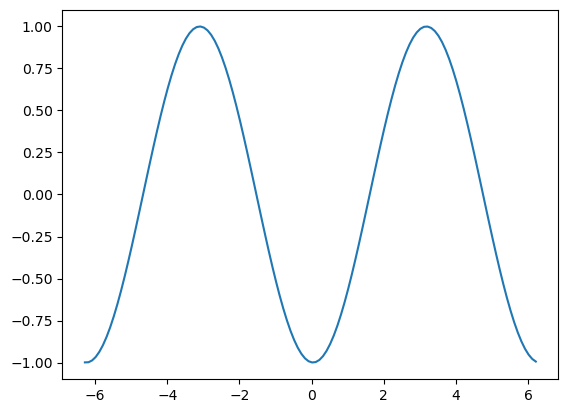

In [6]:
plt.ion()

fig, ax = plt.subplots()

x = np.arange(-2*np.pi, 2*np.pi, 0.1)

line, = ax.plot(x, y)

for delay in np.arange(0, np.pi, 0.1):
    y = np.cos(x + delay)

    line.set_ydata(y)

    plt.draw()
    plt.gcf().canvas.flush_events()

    time.sleep(0.02)

plt.ioff()
plt.show()

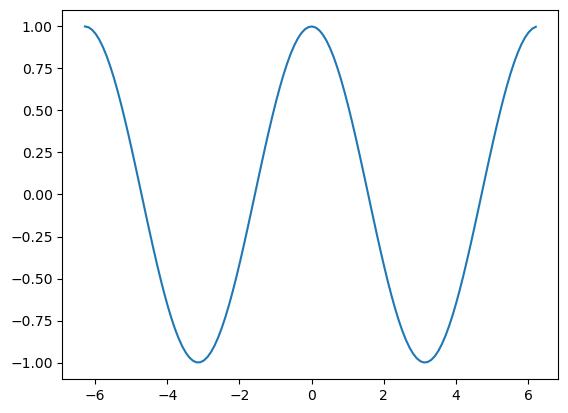

In [8]:
from matplotlib.animation import FuncAnimation

def update_cos(frame, line, x):
    line.set_ydata(np.cos(x + frame))
    return [line]

fig, ax = plt.subplots()

x = np.arange(-2*np.pi, 2*np.pi, 0.1)

line, = ax.plot(x, y)

phasa = np.arange(0, 4*np.pi, 0.1)

animation = FuncAnimation(
    fig,                    #фигура где отображается анимация
    func=update_cos,        #функция обновления текущего кадра
    frames=phasa,           #параметр, меняющийся от кадра к кадру
    fargs=(line, x),        #дополнительные параметры для функции update_cos
    interval=30,            #задержка между кадрами в мс
    blit=True,              #использовать ли двойную буферизацию    
    repeat=False)           #зациклить ли анимацию

plt.show()

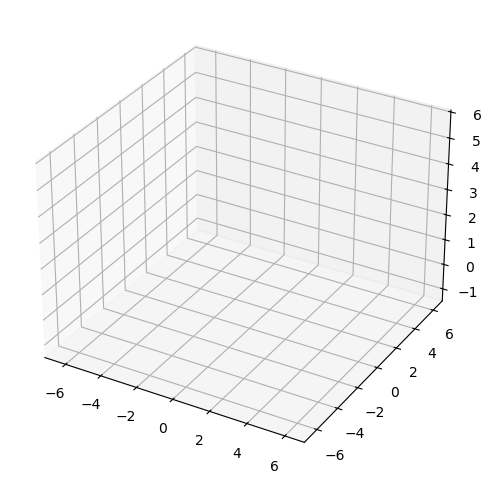

In [9]:
from matplotlib.animation import ArtistAnimation

fig = plt.figure(figsize=(10, 6))
ax_3d = fig.add_subplot(projection='3d')

x = np.arange(-2*np.pi, 2*np.pi, 0.2)
y = np.arange(-2*np.pi, 2*np.pi, 0.2)
xgrid, ygrid = np.meshgrid(x, y)

phasa = np.arange(0, 2*np.pi, 0.1)
frames = []

for p in phasa:
    zgrid = np.sin(xgrid*p) * np.sin(ygrid) / (xgrid * ygrid)

    line = ax_3d.plot_surface(xgrid, ygrid, zgrid, color='b')
    frames.append([line])

animation = ArtistAnimation(
    fig,
    frames,
    interval=30,
    blit=True,
    repeat=True
)

plt.show()